In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
from datetime import datetime

In [2]:
control = pd.read_csv('control_group.csv',delimiter = ';')
control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
test = pd.read_csv('test_group.csv',delimiter = ';')
test.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [4]:
control.columns = ['Campaign Name','Date','Spend Amount','Number of Impressions','Reach','Website Clicks','Searches','Viewed Content','Added to Cart','Purchases']
test.columns = ['Campaign Name','Date','Spend Amount','Number of Impressions','Reach','Website Clicks','Searches','Viewed Content','Added to Cart','Purchases']

In [5]:
control.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Campaign Name          30 non-null     object 
 1   Date                   30 non-null     object 
 2   Spend Amount           30 non-null     int64  
 3   Number of Impressions  29 non-null     float64
 4   Reach                  29 non-null     float64
 5   Website Clicks         29 non-null     float64
 6   Searches               29 non-null     float64
 7   Viewed Content         29 non-null     float64
 8   Added to Cart          29 non-null     float64
 9   Purchases              29 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 2.5+ KB


In [6]:
control['Date'] = pd.to_datetime(control['Date'], dayfirst=True, errors='coerce')
test['Date']= pd.to_datetime(test['Date'],dayfirst=True,errors='coerce')

In [9]:
print(control.isnull().sum())

Campaign Name            0
Date                     0
Spend Amount             0
Number of Impressions    1
Reach                    1
Website Clicks           1
Searches                 1
Viewed Content           1
Added to Cart            1
Purchases                1
dtype: int64


In [15]:
print(test.isnull().sum())

Campaign Name            0
Date                     0
Spend Amount             0
Number of Impressions    0
Reach                    0
Website Clicks           0
Searches                 0
Viewed Content           0
Added to Cart            0
Purchases                0
dtype: int64


In [17]:
control.dropna(subset=control.select_dtypes(include=['int64','float64']).columns, inplace=True)

In [19]:
print(control.isnull().sum())

Campaign Name            0
Date                     0
Spend Amount             0
Number of Impressions    0
Reach                    0
Website Clicks           0
Searches                 0
Viewed Content           0
Added to Cart            0
Purchases                0
dtype: int64


In [21]:
ab_data = control.merge(test,how='outer').sort_values(['Date'])
ab_data = ab_data.reset_index(drop=True)
ab_data.head()

,Campaign Name,Date,Spend Amount,Number of Impressions,Reach,Website Clicks,Searches,Viewed Content,Added to Cart,Purchases
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Test Campaign,2019-08-01,3008,39550.0,35820.0,3038.0,1946.0,1069.0,894.0,255.0
2,Test Campaign,2019-08-02,2542,100719.0,91236.0,4657.0,2359.0,1548.0,879.0,677.0
3,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
4,Test Campaign,2019-08-03,2365,70263.0,45198.0,7885.0,2572.0,2367.0,1268.0,578.0


/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/4227429086.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['control group', 'test group'], y=[total_spend_control,total_spend_test], ax=ax2, palette=['steelblue', 'orange'])


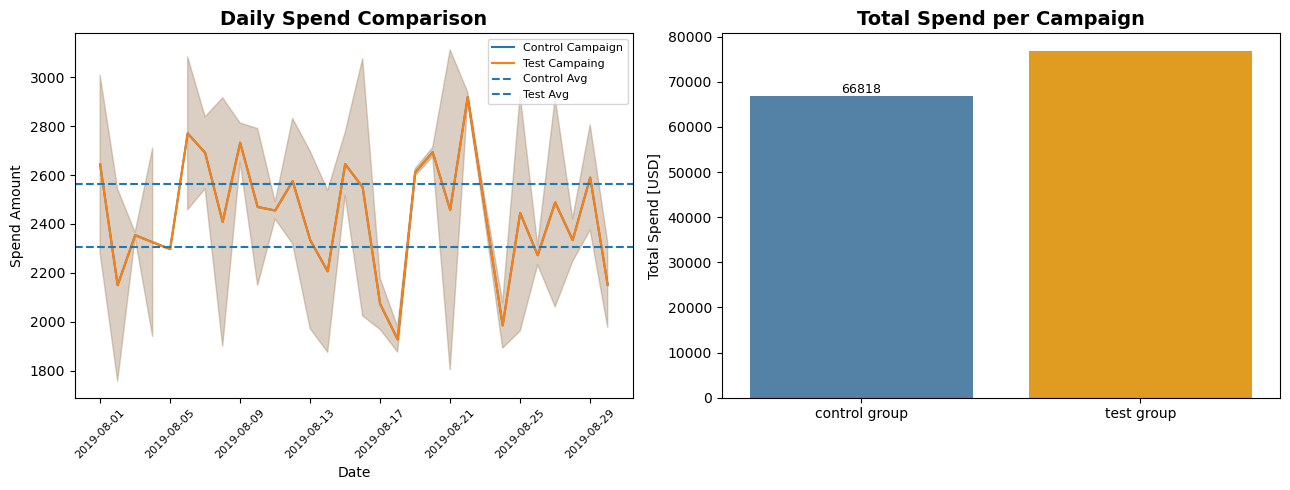

In [23]:
avg_spend_control = ab_data[ab_data['Campaign Name']== 'Control Campaign']['Spend Amount'].mean()
avg_spend_test = ab_data[ab_data['Campaign Name']=='Test Campaign']['Spend Amount'].mean()

total_spend_control = ab_data[ab_data['Campaign Name']== 'Control Campaign']['Spend Amount'].sum()
total_spend_test = ab_data[ab_data['Campaign Name']=='Test Campaign']['Spend Amount'].sum()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

sns.lineplot(data=ab_data, x='Date', y='Spend Amount', label='Control Campaign', ax=ax1)
sns.lineplot(data=ab_data, x='Date', y='Spend Amount', label='Test Campaing', ax=ax1)

ax1.axhline(y=avg_spend_control, ls='--', lw=1.5, label='Control Avg')
ax1.axhline(y=avg_spend_test, ls='--', lw=1.5, label='Test Avg')

ax1.set_title('Daily Spend Comparison', fontsize=14, weight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Spend Amount')
ax1.legend(fontsize=8, loc='upper right')
ax1.tick_params(axis='x', rotation=45, labelsize=8)

sns.barplot(x=['control group', 'test group'], y=[total_spend_control,total_spend_test], ax=ax2, palette=['steelblue', 'orange'])
ax2.set_title('Total Spend per Campaign', fontsize=14, weight='bold')
ax2.set_ylabel('Total Spend [USD]')
ax2.set_xlabel('')
ax2.bar_label(ax2.containers[0], fmt='%.0f', fontsize=9)

plt.tight_layout()
plt.show()

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/59648047.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['control group', 'test group'], y=[total_imp_control,total_imp_test], ax=ax2, palette=['steelblue', 'orange'])


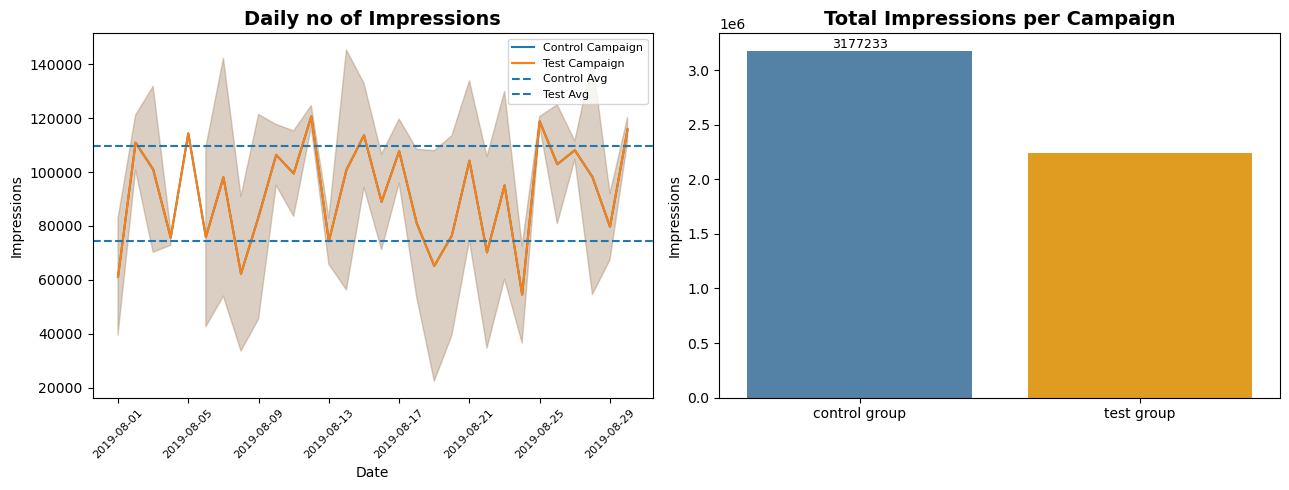

In [24]:
avg_imp_control = ab_data[ab_data['Campaign Name']== 'Control Campaign']['Number of Impressions'].mean()
avg_imp_test = ab_data[ab_data['Campaign Name']=='Test Campaign']['Number of Impressions'].mean()

total_imp_control = ab_data[ab_data['Campaign Name']== 'Control Campaign']['Number of Impressions'].sum()
total_imp_test = ab_data[ab_data['Campaign Name']=='Test Campaign']['Number of Impressions'].sum()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

sns.lineplot(data=ab_data, x='Date', y='Number of Impressions', label='Control Campaign', ax=ax1)
sns.lineplot(data=ab_data, x='Date', y='Number of Impressions', label='Test Campaign', ax=ax1)

ax1.axhline(y=avg_imp_control, ls='--', lw=1.5, label='Control Avg')
ax1.axhline(y=avg_imp_test, ls='--', lw=1.5, label='Test Avg')

ax1.set_title('Daily no of Impressions', fontsize=14, weight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Impressions')
ax1.legend(fontsize=8, loc='upper right')
ax1.tick_params(axis='x', rotation=45, labelsize=8)

sns.barplot(x=['control group', 'test group'], y=[total_imp_control,total_imp_test], ax=ax2, palette=['steelblue', 'orange'])
ax2.set_title('Total Impressions per Campaign', fontsize=14, weight='bold')
ax2.set_ylabel('Impressions')
ax2.set_xlabel('')
ax2.bar_label(ax2.containers[0], fmt='%.0f', fontsize=9)

plt.tight_layout()
plt.show()

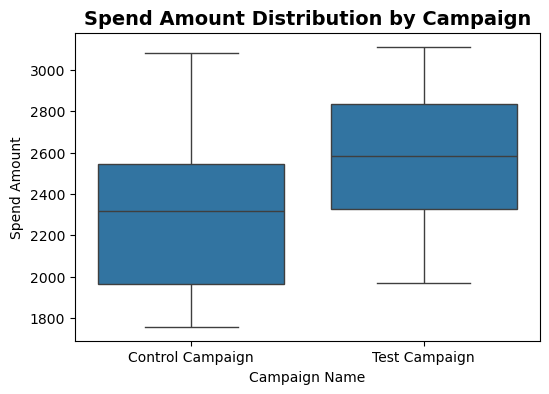

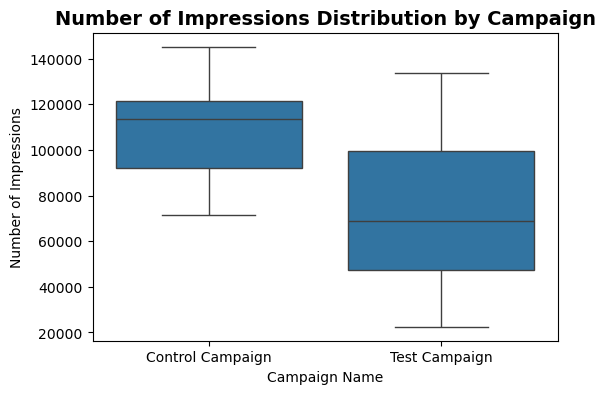

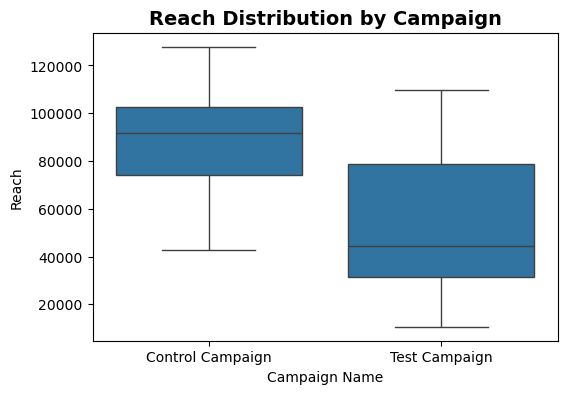

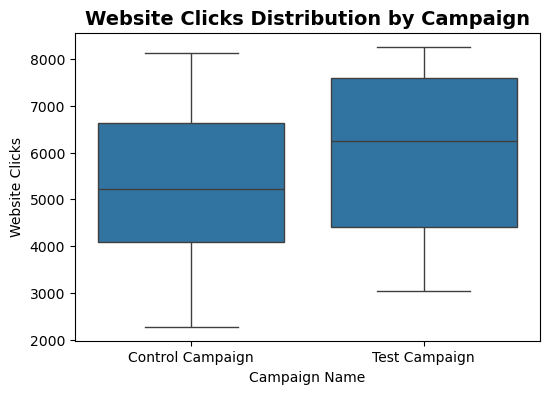

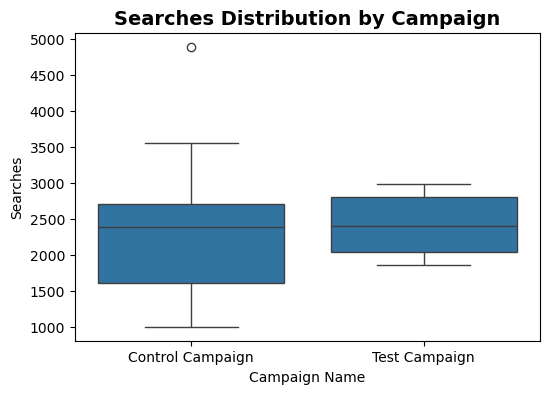

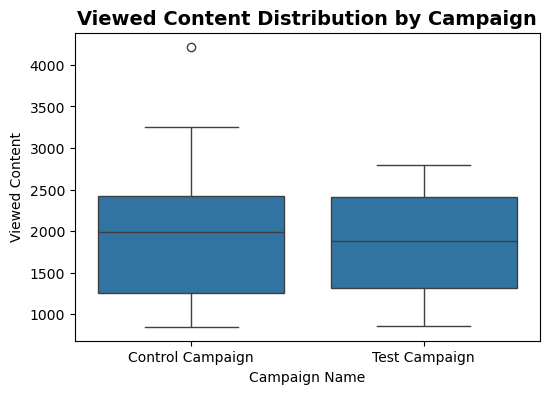

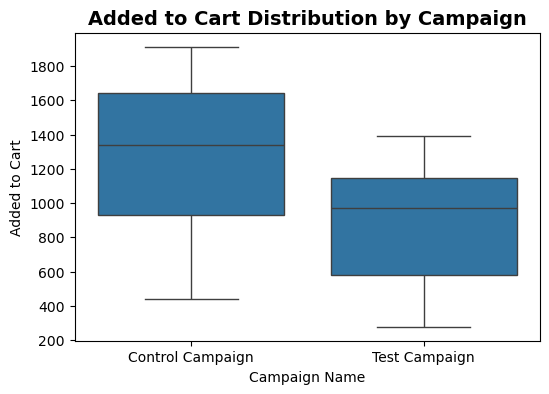

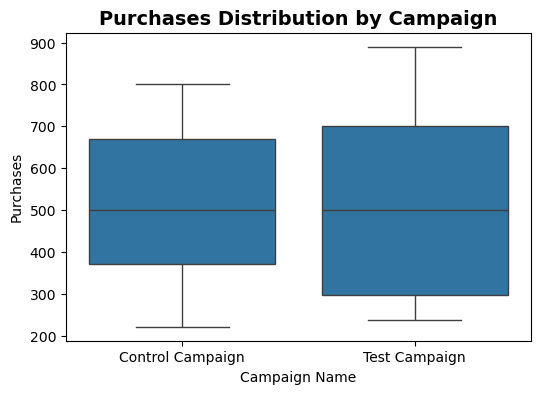

In [26]:
num_cols = ab_data.select_dtypes(include = ['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Campaign Name', y=col, data=ab_data)
    plt.title(f'{col} Distribution by Campaign', fontsize=14, weight='bold')
    plt.ylabel(col)
    plt.show()

In [29]:
outlier_summary = []
campaigns = ab_data['Campaign Name'].unique()

for campaign in campaigns:
    df_campaign = ab_data[ab_data['Campaign Name'] == campaign]
    for col in num_cols:
        Q1 = ab_data[col].quantile(0.25)
        Q3 = ab_data[col].quantile(0.75)
        IQR = Q3 - Q1

        outliers = ab_data[(ab_data[col] < Q1 - 1.5*IQR) | (ab_data[col] > Q3 + 1.5*IQR)]
        outlier_count = len(outliers)
        total_count = len(ab_data)
        outlier_percentage = (outlier_count / total_count) * 100

    
        if outlier_percentage < 5:
            recommendation = 'Keep (small percentage)'
        elif outlier_percentage < 10:
            recommendation = 'Consider capping or checking'
        else:
            recommendation = 'Investigate/remove'

    
        outlier_summary.append({
            "Campaign":campaign,
            'Feature': col,
            'Outlier Count': outlier_count,
            'Outlier %': round(outlier_percentage, 2),
            'Recommendation': recommendation
            })

# Convert to DataFrame for easy viewing
outlier_summary_df = pd.DataFrame(outlier_summary)
print(outlier_summary_df)


            Campaign                Feature  Outlier Count  Outlier %  \
0   Control Campaign           Spend Amount              0       0.00   
1   Control Campaign  Number of Impressions              0       0.00   
2   Control Campaign                  Reach              0       0.00   
3   Control Campaign         Website Clicks              0       0.00   
4   Control Campaign               Searches              1       1.69   
5   Control Campaign         Viewed Content              1       1.69   
6   Control Campaign          Added to Cart              0       0.00   
7   Control Campaign              Purchases              0       0.00   
8      Test Campaign           Spend Amount              0       0.00   
9      Test Campaign  Number of Impressions              0       0.00   
10     Test Campaign                  Reach              0       0.00   
11     Test Campaign         Website Clicks              0       0.00   
12     Test Campaign               Searches        

In [31]:
## Metrics

continuous_metrics = ['Spend Amount', 'Number of Impressions', 
                      'Website Clicks', 'Viewed Content', 'Added to Cart', 'Purchases']

ab_data['CTR'] = ab_data['Website Clicks'] / ab_data['Number of Impressions'] #Click through rate
ab_data['Add_to_Cart_Rate'] = ab_data['Added to Cart'] / ab_data['Viewed Content']
ab_data['Conversion_Rate'] = ab_data['Purchases'] / ab_data['Website Clicks']
ab_data['CostperClick'] = ab_data['Spend Amount']/ ab_data['Website Clicks']
ab_data['CostperPurchase'] = ab_data['Spend Amount']/ ab_data['Purchases']

proportion_metrics = ['CTR', 'Add_to_Cart_Rate', 'Conversion_Rate','CostperClick','CostperPurchase']


daily_metrics = ab_data.groupby(['Campaign Name', 'Date'])[continuous_metrics + proportion_metrics].sum().reset_index()

campaign_summary = daily_metrics.groupby('Campaign Name')[continuous_metrics + proportion_metrics].agg(['mean','median','std']).reset_index()


In [33]:
daily_metrics

,Campaign Name,Date,Spend Amount,Number of Impressions,Website Clicks,Viewed Content,Added to Cart,Purchases,CTR,Add_to_Cart_Rate,Conversion_Rate,CostperClick,CostperPurchase
0,Control Campaign,2019-08-01,2280,82702.0,7016.0,2159.0,1819.0,618.0,0.084835,0.842520,0.088084,0.324971,3.689320
1,Control Campaign,2019-08-02,1757,121040.0,8110.0,1841.0,1219.0,511.0,0.067003,0.662140,0.063009,0.216646,3.438356
2,Control Campaign,2019-08-03,2343,131711.0,6508.0,1549.0,1134.0,372.0,0.049411,0.732085,0.057160,0.360018,6.298387
3,Control Campaign,2019-08-04,1940,72878.0,3065.0,982.0,1183.0,340.0,0.042057,1.204684,0.110930,0.632953,5.705882
4,Control Campaign,2019-08-06,3083,109076.0,4028.0,1249.0,784.0,764.0,0.036928,0.627702,0.189672,0.765392,4.035340
5,Control Campaign,2019-08-07,2544,142123.0,2640.0,1106.0,1166.0,499.0,0.018575,1.054250,0.189015,0.963636,5.098196
6,Control Campaign,2019-08-08,1900,90939.0,7260.0,2746.0,930.0,462.0,0.079834,0.338674,0.063636,0.261708,4.112554
7,Control Campaign,2019-08-09,2813,121332.0,6198.0,2179.0,645.0,501.0,0.051083,0.296007,0.080833,0.453856,5.614770
8,Control Campaign,2019-08-10,2149,117624.0,2277.0,1984.0,1629.0,734.0,0.019358,0.821069,0.322354,0.943786,2.927793
9,Control Campaign,2019-08-11,2490,115247.0,8137.0,2486.0,1887.0,475.0,0.070605,0.759051,0.058375,0.306010,5.242105


--- CTR ---
Control Campaign: W=0.955, p=0.245 -> Normal


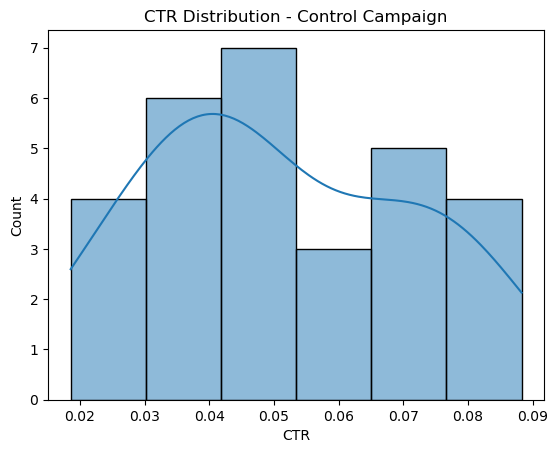

--- Add_to_Cart_Rate ---
Control Campaign: W=0.911, p=0.018 -> Not Normal


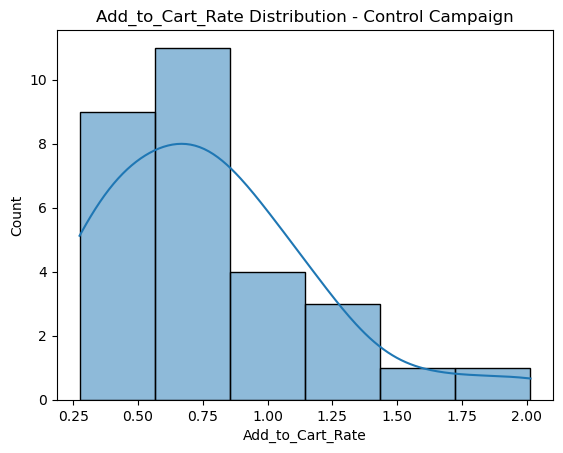

--- Conversion_Rate ---
Control Campaign: W=0.895, p=0.007 -> Not Normal


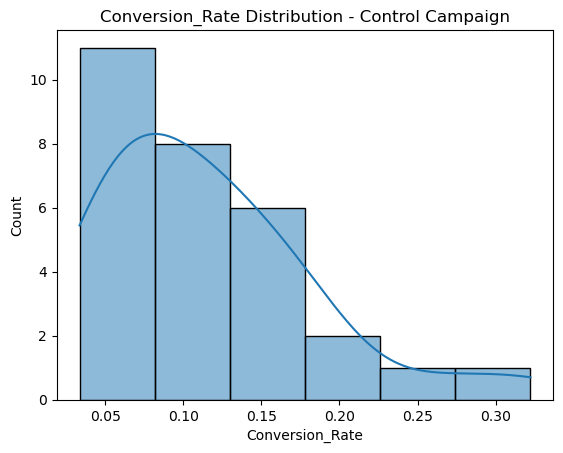

--- CostperClick ---
Control Campaign: W=0.877, p=0.003 -> Not Normal


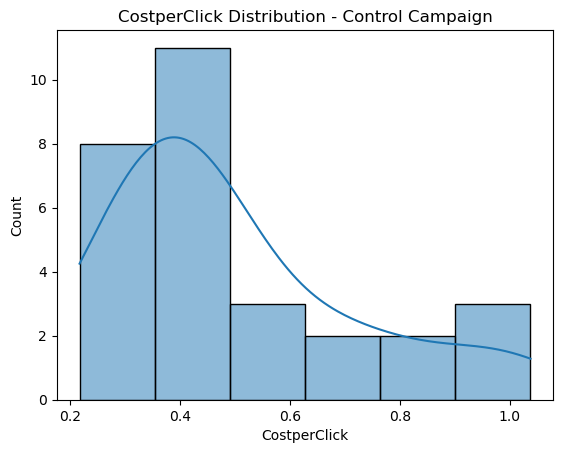

--- CostperPurchase ---
Control Campaign: W=0.913, p=0.021 -> Not Normal


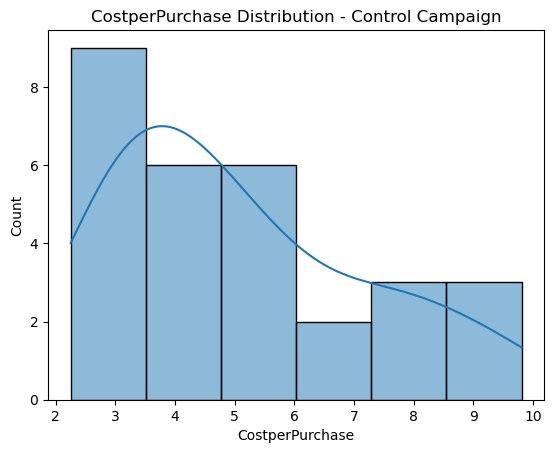

In [35]:
metrics = ['CTR', 'Add_to_Cart_Rate', 'Conversion_Rate', 'CostperClick', 'CostperPurchase']

for metric in metrics:
    print(f"--- {metric} ---")
    data = daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][metric]
        
    stat, p = st.shapiro(data)
    normality = 'Normal' if p > 0.05 else 'Not Normal'
    print(f"Control Campaign: W={stat:.3f}, p={p:.3f} -> {normality}")
        
    sns.histplot(data, kde=True)
    plt.title(f"{metric} Distribution - Control Campaign")
    plt.show()


--- CTR ---
Test Campaign: W=0.841, p=0.000 -> Not Normal


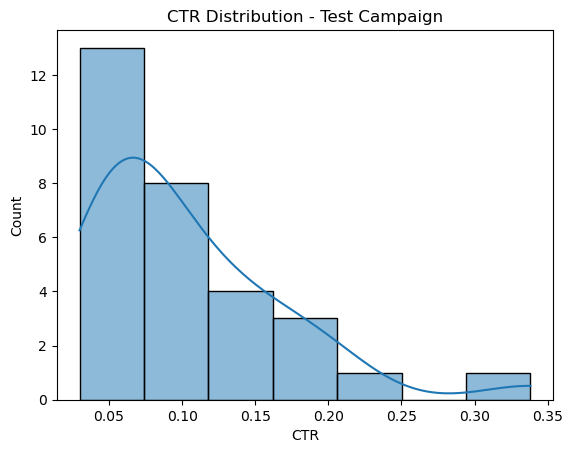

--- Add_to_Cart_Rate ---
Test Campaign: W=0.973, p=0.621 -> Normal


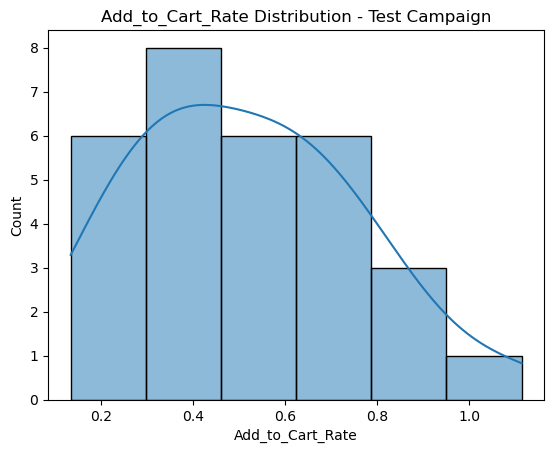

--- Conversion_Rate ---
Test Campaign: W=0.925, p=0.037 -> Not Normal


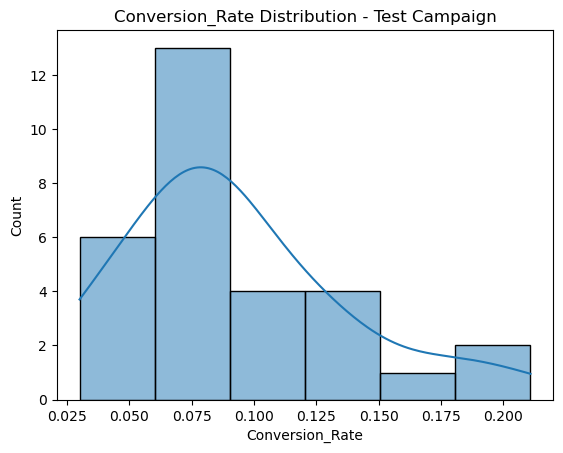

--- CostperClick ---
Test Campaign: W=0.911, p=0.016 -> Not Normal


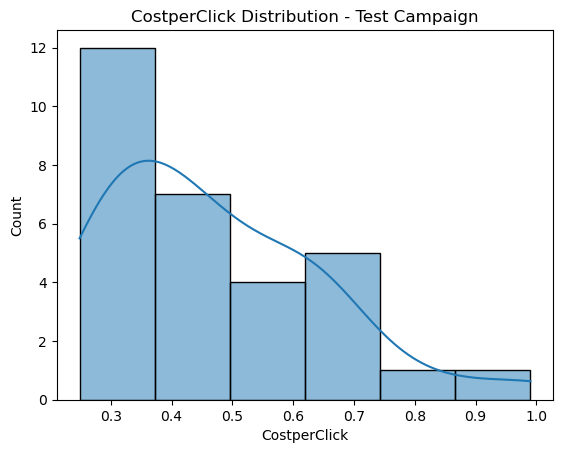

--- CostperPurchase ---
Test Campaign: W=0.897, p=0.007 -> Not Normal


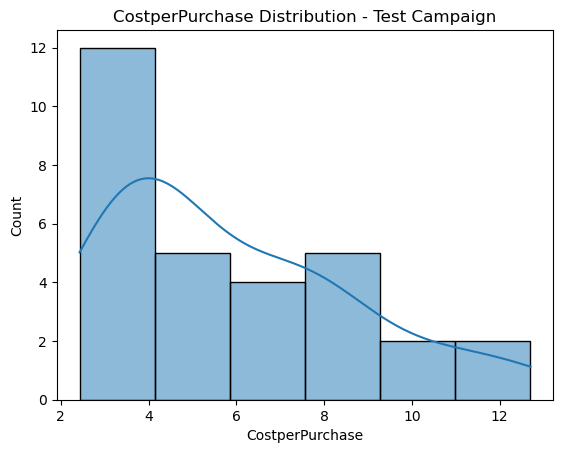

In [39]:
metrics = ['CTR', 'Add_to_Cart_Rate', 'Conversion_Rate', 'CostperClick', 'CostperPurchase']

for metric in metrics:
    print(f"--- {metric} ---")
    data = daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][metric]
        
    stat, p = st.shapiro(data)
    normality = 'Normal' if p > 0.05 else 'Not Normal'
    print(f"Test Campaign: W={stat:.3f}, p={p:.3f} -> {normality}")
        
    sns.histplot(data, kde=True)
    plt.title(f"{metric} Distribution - Test Campaign")
    plt.show()

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/2222350742.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), size=7)


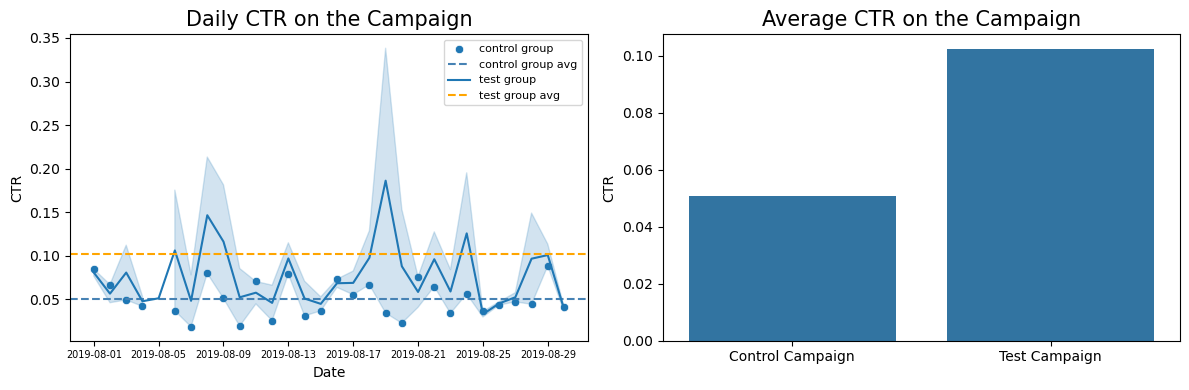

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/2222350742.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), size=7)


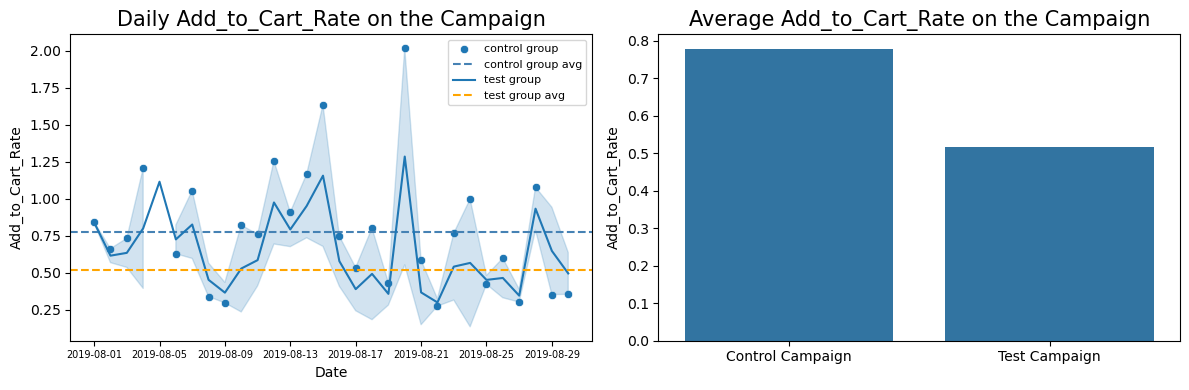

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/2222350742.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), size=7)


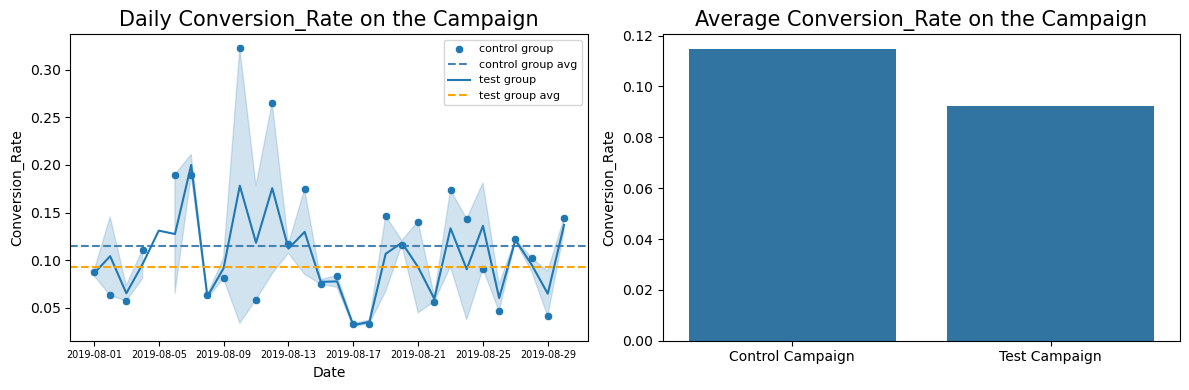

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/2222350742.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), size=7)


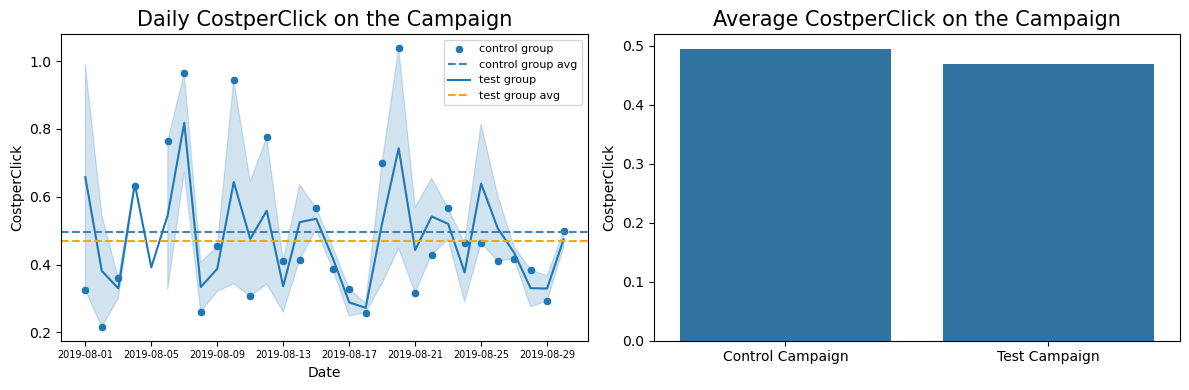

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_35973/2222350742.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), size=7)


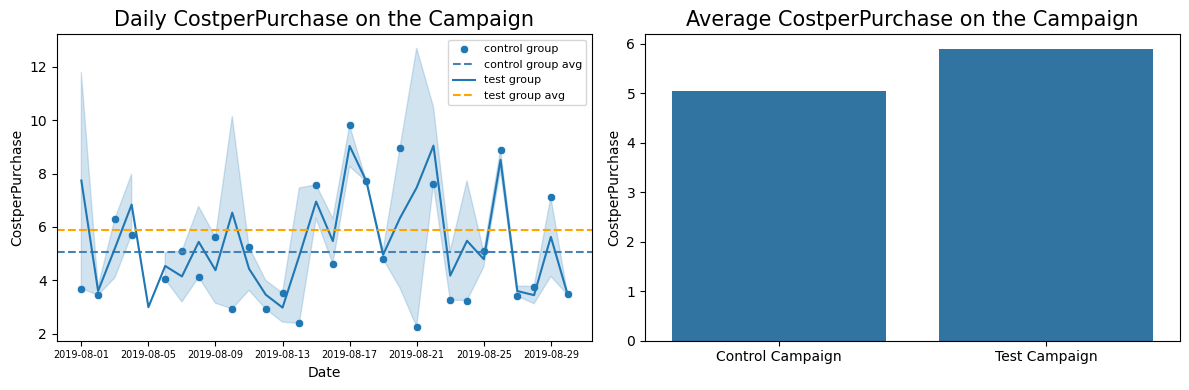

In [41]:
for metric in metrics:

    avg_control = daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][metric].mean()
    avg_test    = daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][metric].mean()
    x_metric = ['Control Campaign','Test Campaign']
    y_metric = [avg_control, avg_test]

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,4))

    ax1 = sns.scatterplot(data=daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'], x='Date', y=metric, label='control group', ax=ax1)
    ax1.axhline(y=avg_control, color='steelblue', ls='--', label='control group avg')

    ax1 = sns.lineplot(data=daily_metrics, x='Date', y=metric, label='test group', ax=ax1)
    ax1.axhline(y=avg_test, ls='--', color='orange', label='test group avg')

    ax1.set_title(f'Daily {metric} on the Campaign', size=15)
    ax1.legend(fontsize=8)
    ax1.set_xticklabels(ax1.get_xticklabels(), size=7)

    ax2 = sns.barplot(x=x_metric, y=y_metric)
    ax2.set_ylabel(f'{metric}')
    ax2.set_title(f'Average {metric} on the Campaign', size=15)

    plt.tight_layout()
    plt.show()


In [45]:
##Levene's test - Homogenity of Variances

for metric in metrics:
    levene_test = st.levene(daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][metric], 
                            daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][metric])
    print(f"\nLevene's Test for Homogeneity of Variances: {metric}")
    print(f"Statistic = {levene_test.statistic}, p-value = {levene_test.pvalue}")





Levene's Test for Homogeneity of Variances: CTR
Statistic = 9.708363311802788, p-value = 0.0028710678021290643

Levene's Test for Homogeneity of Variances: Add_to_Cart_Rate
Statistic = 3.335477995697067, p-value = 0.07303934132033295

Levene's Test for Homogeneity of Variances: Conversion_Rate
Statistic = 3.432584244695148, p-value = 0.06910165314376529

Levene's Test for Homogeneity of Variances: CostperClick
Statistic = 0.27627669822832746, p-value = 0.6011909897290859

Levene's Test for Homogeneity of Variances: CostperPurchase
Statistic = 1.6975387977818608, p-value = 0.19784927416939832


In [49]:
## Only CTR Reject Null Hypothesis p<0.05 - Variances differ
## THe rest have homogenous variances

In [47]:
for metric in metrics:
    control_data = daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][metric].dropna()
    test_data    = daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][metric].dropna()

    stat, p = st.mannwhitneyu(control_data, test_data, alternative='two-sided')
    print(f"{metric}: Mann-Whitney U = {stat:.3f}, p-value = {p:.3f}")


CTR: Mann-Whitney U = 193.000, p-value = 0.000
Add_to_Cart_Rate: Mann-Whitney U = 609.000, p-value = 0.009
Conversion_Rate: Mann-Whitney U = 503.000, p-value = 0.306
CostperClick: Mann-Whitney U = 450.000, p-value = 0.826
CostperPurchase: Mann-Whitney U = 362.000, p-value = 0.272


In [51]:
#Significant difference - CTR differs between Control and Test
#Significant difference — Add-to-Cart Rate differs
#Not significant — Conversion Rate similar
#Not significant — Cost per Click similar
#Not significant — Cost per Purchase similar

In [53]:
#Conclusion
#CTR = Test campaign significantly changed user engagement — people clicked more or less.
#Add to Cart = RateTest campaign influenced user intent (added products to cart more/less).
#Conversion rate = The rate of completed purchases didn’t change meaningfully.
#Cost per Click/Purchase = The spending efficiency per action is statistically the same.